# MLP/NN - Nada

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
!pip install eli5 lime shap
import eli5
from eli5.sklearn import PermutationImportance
from sklearn.inspection import PartialDependenceDisplay
from lime import lime_tabular
import shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 7.1 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=66bf206166658593dcc35dce06472495776c641f1fe762202a5163ed76b2035a
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
x = data.drop(columns=["stroke_risk_percentage"])
y = data["stroke_risk_percentage"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [ ]:
nn = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=0
)

history = nn.fit(x_train, y_train)

In [ ]:
predictions = nn.predict(x_test)

In [ ]:
MSE = mean_squared_error(y_test, predictions)

MAE = mean_absolute_error(y_test, predictions)

R2 = r2_score(y_test, predictions)

print(f"Mean Squared Error: {MSE}")
print(f'Mean Absolute Error (MAE): {MAE}')
print(f'R-squared (R2): {R2}')

Mean Squared Error: 52.32561909447593
Mean Absolute Error (MAE): 5.565942578202449
R-squared (R2): 0.9453839009669573


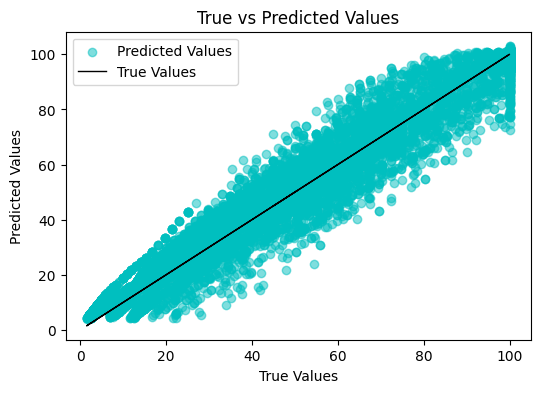

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(y_test, predictions, c="c", alpha=0.5, label="Predicted Values")

ax.plot(y_test, y_test, c="k", lw=1, label="True Values")

ax.set_xlabel('True Values')
ax.set_ylabel('Predicted Values')
ax.set_title('True vs Predicted Values')
ax.legend()

In [ ]:
perm = PermutationImportance(nn, random_state=0).fit(x_test, y_test)
display(eli5.show_weights(perm, feature_names=x.columns.tolist()))

Weight,Feature
0.8690 ± 0.0079,age
0.1345 ± 0.0028,high_blood_pressure
0.0887 ± 0.0030,chest_pain
0.0624 ± 0.0018,shortness_of_breath
0.0532 ± 0.0023,chest_discomfort
0.0523 ± 0.0012,snoring_sleep_apnea
0.0385 ± 0.0018,irregular_heartbeat
0.0340 ± 0.0012,fatigue_weakness
0.0275 ± 0.0009,dizziness
0.0163 ± 0.0003,neck_jaw_pain


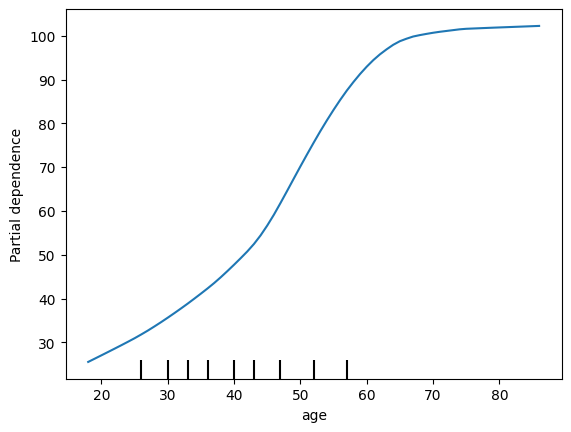

In [ ]:
PartialDependenceDisplay.from_estimator(nn, x, features=[0])

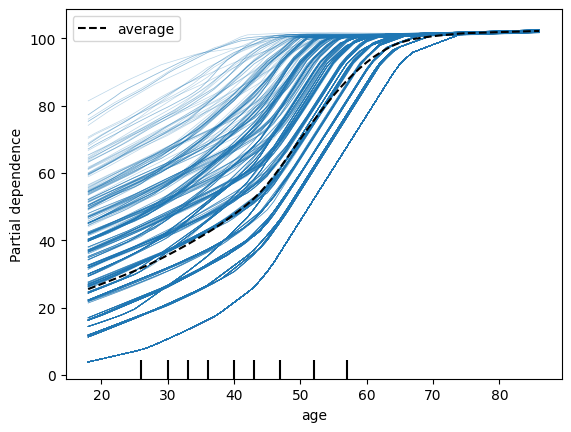

In [ ]:
#ICE plot with PDP
PartialDependenceDisplay.from_estimator(nn, x, features=[0], kind="both", pd_line_kw={'color': 'black'})

<Axes: xlabel='importance', ylabel='feature'>

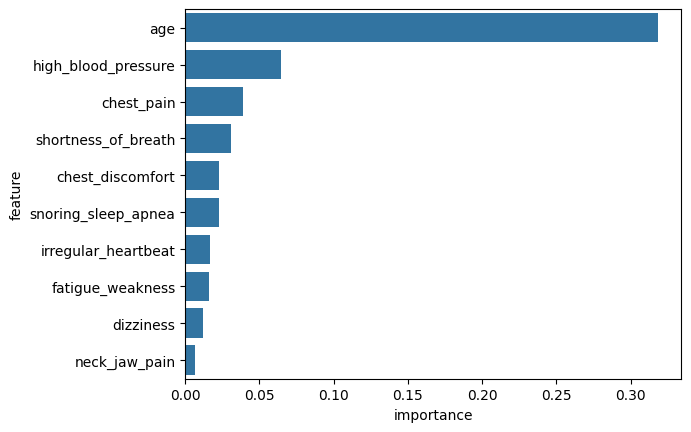

In [66]:
importance = []

nn2 = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=0
)

for col in x.columns:
  x_col_removed = x.drop(columns=[col])
  x_train2, x_test2, y_train2, y_test2 = train_test_split(x_col_removed, y, test_size=0.2, random_state=0)

  history2 = nn2.fit(x_train2, y_train2)

  predictions2 = nn2.predict(x_test2)
  R2_cols_rem = r2_score(y_test2, predictions2)

  difference = R2 - R2_cols_rem
  importance.append({"feature": col, "importance": difference})

res_df = pd.DataFrame(importance)
res_df = res_df.sort_values(by="importance", ascending=False)

sns.barplot(data=res_df, x="importance", y="feature")

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

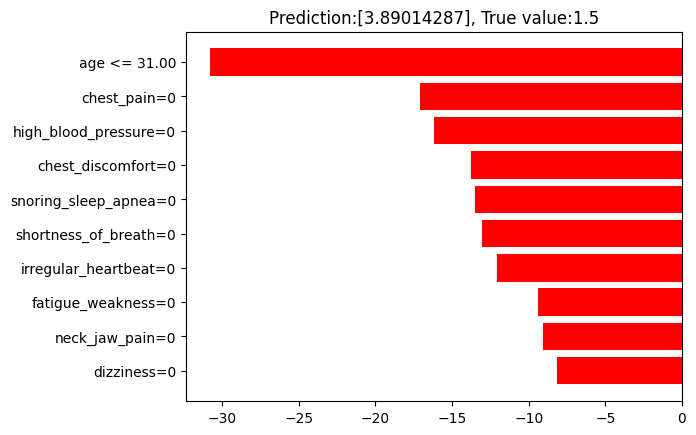

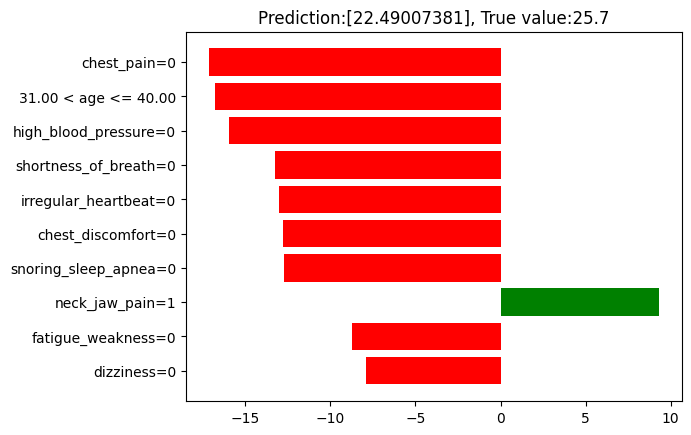

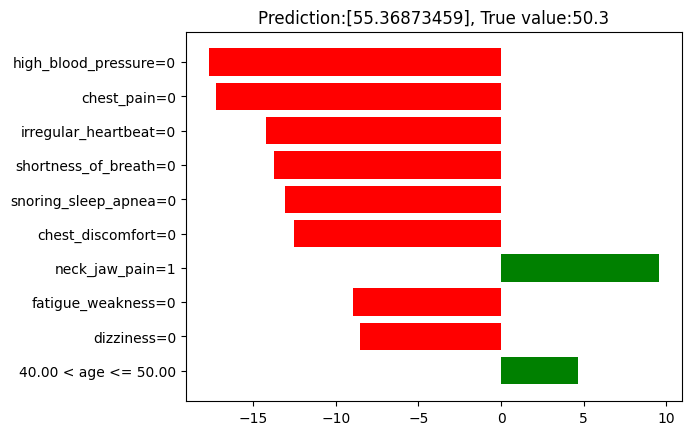

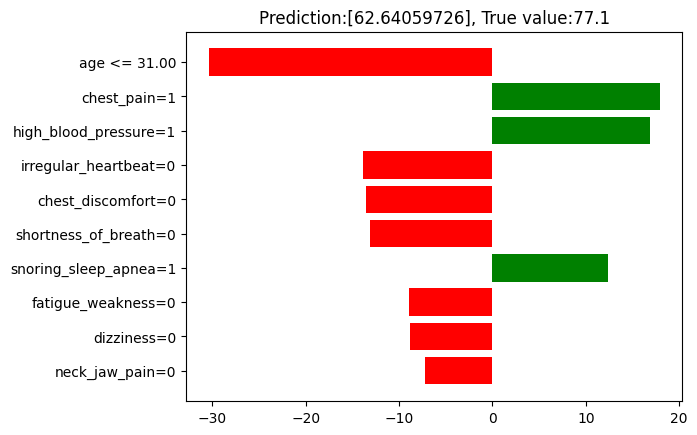

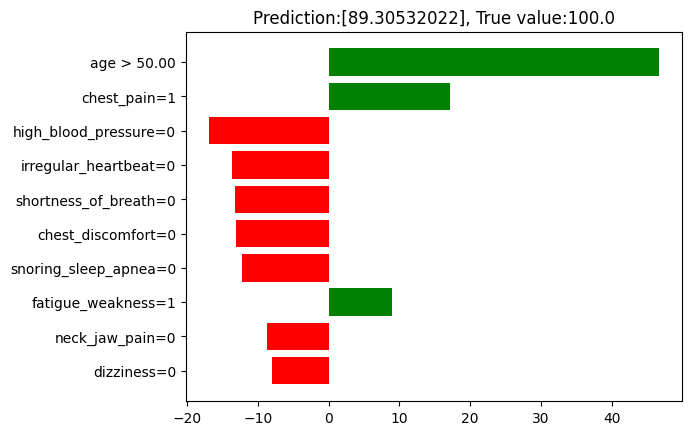

In [68]:
explainer = lime_tabular.LimeTabularExplainer(training_data=x_train.to_numpy(), feature_names=x.columns, categorical_features=[1,2,3,4,5,6,7,8,9], mode="regression")

def model_predict(data):
  return nn.predict(data)

def get_examples(x_test, y_test):
  examples = {}
  ranges = [0,25,50,75,100]
  percentiles = np.percentile(y_test,ranges)
  for p in percentiles:
    index = np.argmin(np.abs(y_test - p))
    examples[index] = x_test.iloc[index]

  return examples

examples = get_examples(x_test, y_test)

for i, item in examples.items():
    explanation = explainer.explain_instance(
        data_row=item,
        predict_fn=model_predict,
        num_features=10
    )

    explanation.as_pyplot_figure()
    plt.title("Prediction:" + str(nn.predict(x_test.iloc[[i]])) + ", True value:" + str(y_test.iloc[i]))

In [71]:
def get_examples_shap(x_test, y_test):
  examples = []
  ranges = [0,25,50,75,100]
  percentiles = np.percentile(y_test,ranges)
  for p in percentiles:
    index = np.argmin(np.abs(y_test - p))
    examples.append(x_test.iloc[index])

  return examples

examples2 = get_examples_shap(x_test, y_test)

background = x_train.iloc[np.random.choice(x_train.shape[0], 100, replace=False)]
explainer = shap.KernelExplainer(model_predict, background)

shap_values = explainer.shap_values(pd.DataFrame(examples2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


  0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/valida

In [72]:
shap.initjs()
for i in range(5):
  display(shap.force_plot(
      explainer.expected_value,
      shap_values[i],
      examples2[i]
  ))

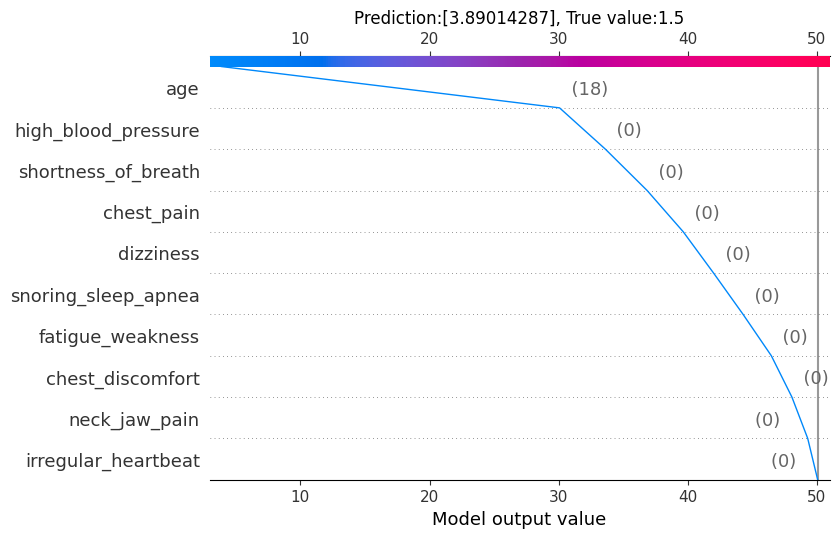

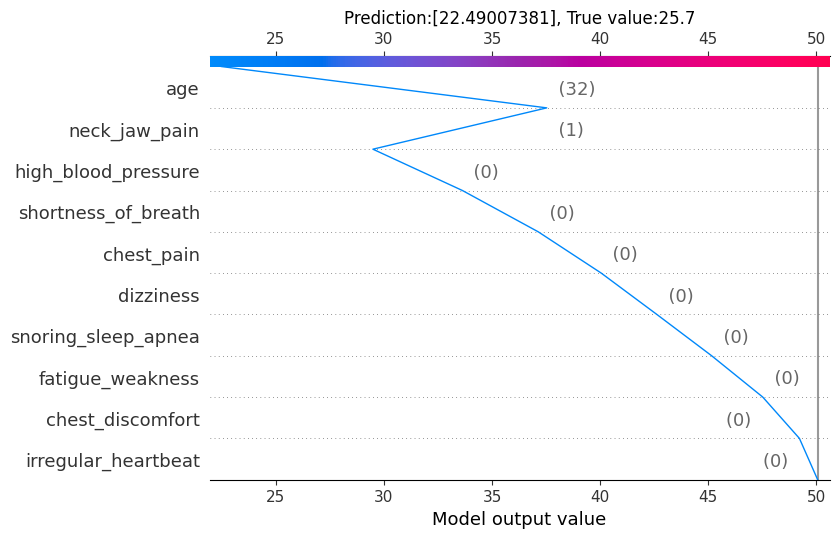

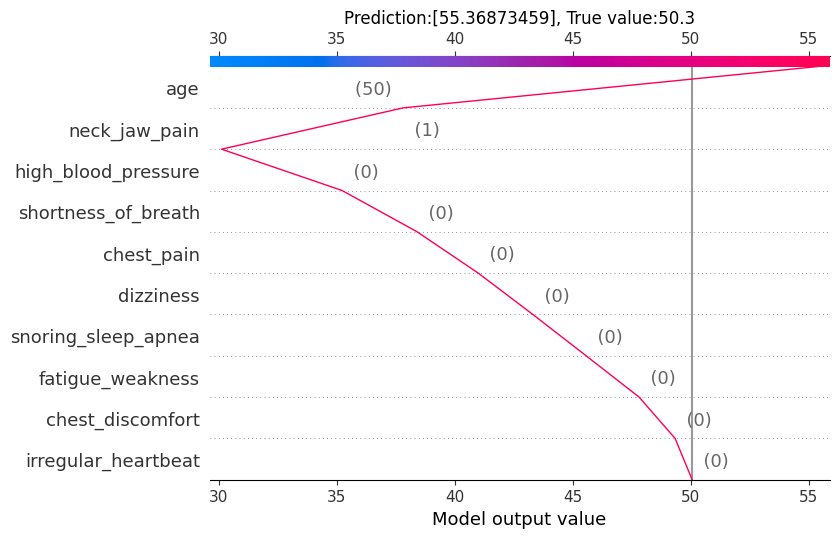

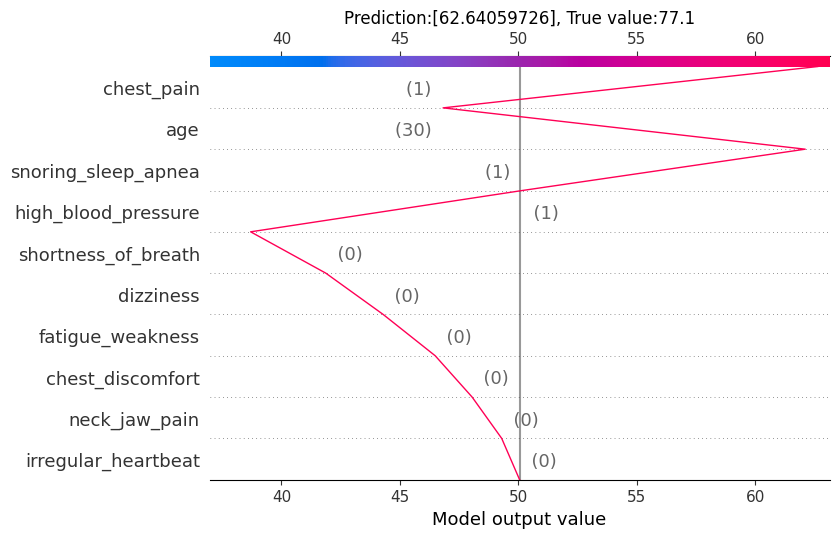

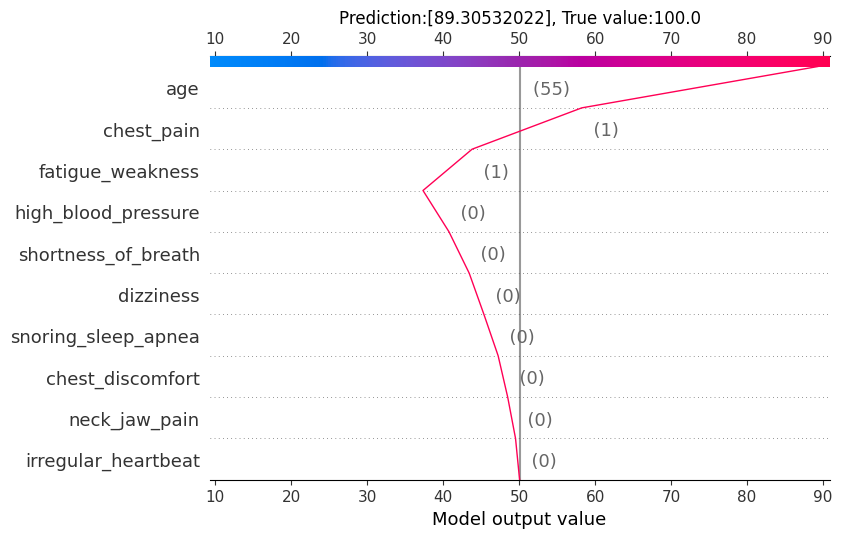

In [111]:
for i, j in zip(range(5), examples.keys()):
  shap.decision_plot(
      explainer.expected_value,
      shap_values[i],
      examples2[i],
      show=False
  )
  plt.title("Prediction:" + str(nn.predict(x_test.iloc[[j]])) + ", True value:" + str(y_test.iloc[j]))
  plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

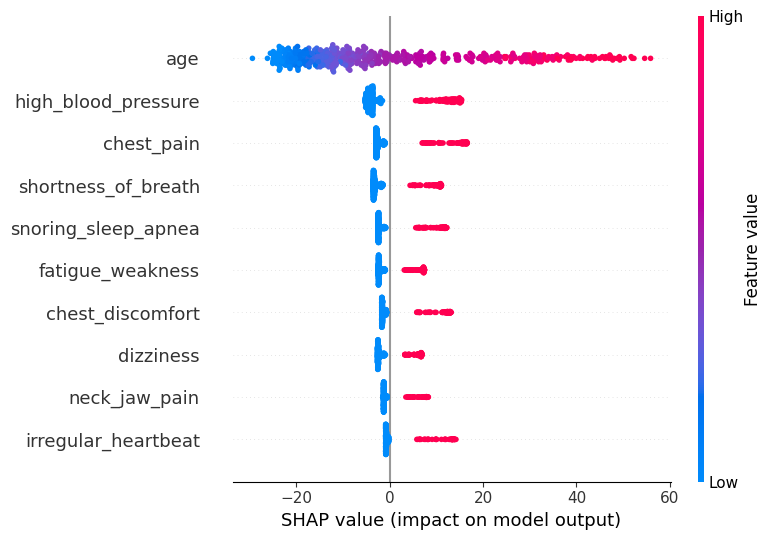

In [76]:
x_test_sample = x_test.sample(500, random_state=0)
shap_values2 = explainer.shap_values(x_test_sample)
shap.summary_plot(shap_values2, x_test_sample)